In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings
from tqdm import tqdm

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa

In [2]:
# Read config file
config = load_config("conf_local.yaml")

# Results folder: a single one for the whole hyperparameter grid; each row
# of df_tot.csv carries its own n_clients/ess/prob_shift/alpha combination.
res_path = Path(config["res_path"])

# Read results: all weighting schemas x all grid combinations, one row per
# (n_clients, ess, prob_shift, alpha, size, rep).
df_tot = pd.read_csv(res_path / f"df_tot.csv")

In [3]:
# Per-repetition relative gain of each MOSAIC schema over plain IDM on mean
# JSD (positive = MOSAIC closer to the ground truth than IDM alone).
GAIN_COLS = [f"gain_w{w}" for w in (2, 3)]
for w in (2, 3):
    df_tot[f"gain_w{w}"] = (df_tot["idm_mean"] - df_tot[f"mos_w{w}_mean"]) / df_tot[
        "idm_mean"
    ]

CONTAIN_COLS = ["idm_gt_contained"] + [f"mos_w{w}_gt_contained" for w in (2, 3)]
JSD_COLS = (
    ["mle", "idm_mean", "idm_max"]
    + [f"mos_w{w}_mean" for w in (2, 3)]
    + [f"mos_w{w}_max" for w in (2, 3)]
)

# Aggregated by every grid hyperparameter, not just size. Both mean+std and
# median+Q1/Q3 are kept, so CENTRAL_STAT can switch later without redoing this.
group_cols = ["n_clients", "ess", "prob_shift", "alpha", "size"]
AGG_COLS = GAIN_COLS + CONTAIN_COLS + JSD_COLS

g = df_tot.groupby(group_cols)[AGG_COLS]
agg_mean = g.mean()
agg_mean.columns = [f"{c}_mean" for c in agg_mean.columns]
agg_std = g.std()
agg_std.columns = [f"{c}_std" for c in agg_std.columns]
agg_median = g.median()
agg_median.columns = [f"{c}_median" for c in agg_median.columns]
agg_q1 = g.quantile(0.25)
agg_q1.columns = [f"{c}_q1" for c in agg_q1.columns]
agg_q3 = g.quantile(0.75)
agg_q3.columns = [f"{c}_q3" for c in agg_q3.columns]

df_mean = pd.concat(
    [agg_mean, agg_std, agg_median, agg_q1, agg_q3], axis=1
).reset_index()

# intersection_frac keeps median+Q1/Q3 regardless of CENTRAL_STAT: its
# distribution is skewed enough that the mean can fall below Q1.
df_mean["intersection_frac_median"] = (
    df_tot.groupby(group_cols)["intersection_frac"].median().to_numpy()
)
df_mean["intersection_frac_q1"] = (
    df_tot.groupby(group_cols)["intersection_frac"].quantile(0.25).to_numpy()
)
df_mean["intersection_frac_q3"] = (
    df_tot.groupby(group_cols)["intersection_frac"].quantile(0.75).to_numpy()
)
# df_mean.head()

In [4]:
sns.reset_defaults()
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update(
    {
        # base
        "figure.figsize": [7, 4],
        "font.size": 13.5,
        # axes
        "axes.labelsize": 13.5,
        "axes.titlesize": 13.5,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "black",
        # legend
        "legend.fontsize": 9,
        # "legend.labelspacing": 0.3,
        # ticks
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        # lines
        "lines.linewidth": 1.0,
        # dpi
        "figure.dpi": 300,
        "savefig.dpi": 300,
        # tex
        "text.usetex": True,
    }
)

# Per-subplot size (inches); the total figure size is this times the
# grid's row/column count.
SUBPLOT_WIDTH = 4
SUBPLOT_HEIGHT = 2.5

# Fontsize of each facet's column title (top row only) and row label (the
# first line of the leftmost column's y-axis label). Scaled to match this
# notebook's total figure width (SUBPLOT_WIDTH * n_cols = 12in) against the
# 8in/9pt reference used across the other plotting notebooks.
COL_TITLE_FONTSIZE = 13.5
ROW_LABEL_FONTSIZE = 13.5

# Across-repetition spread is shown as sparse whisker markers, not a
# fill_between band (that's reserved for Plot 1's credal-set width).
CENTRAL_STAT = "median"  # "mean" or "median"

N_WHISKER_MARKERS = 5  # how many markers per curve
WHISKER_DODGE = 8  # horizontal offset (in N units) between methods' markers

# Global knobs for every plot below: curve line width, and whisker
# error-bar (and cap) line width.
CURVE_LINEWIDTH = 1.4
WHISKER_LINEWIDTH = 1


def add_std_whiskers(
    ax, x, y, err, color, dodge=0.0, n_markers=N_WHISKER_MARKERS, clip_lower=None
):
    """
    Sparse dot-whisker markers for the across-repetition spread around a
    mean/median line. `err` is either a symmetric half-width (e.g. std) or
    an (lower_half, upper_half) pair of arrays for an asymmetric interval
    (e.g. an IQR). `clip_lower` floors the lower whisker (e.g. for a
    log-scale axis, where a non-positive bound would be invalid).
    """
    x, y = np.asarray(x), np.asarray(y)
    idx = np.linspace(0, len(x) - 1, n_markers).astype(int)
    wx, wy = x[idx] + dodge, y[idx]
    if isinstance(err, tuple):
        lo_half, hi_half = np.asarray(err[0])[idx], np.asarray(err[1])[idx]
    else:
        lo_half = hi_half = np.asarray(err)[idx]
    lo, hi = wy - lo_half, wy + hi_half
    if clip_lower is not None:
        lo = np.clip(lo, clip_lower, None)
    ax.errorbar(
        wx,
        wy,
        yerr=[wy - lo, hi - wy],
        fmt="o",
        color=color,
        markersize=3,
        markeredgecolor="white",
        markeredgewidth=0.4,
        elinewidth=WHISKER_LINEWIDTH,
        capsize=2.5,
        capthick=WHISKER_LINEWIDTH,
        zorder=5,
    )


def center_spread(sub, col):
    """
    (center, spread) for `col`'s across-repetition aggregate, matched to
    CENTRAL_STAT: mean+std (spread is a single symmetric half-width) or
    median+Q1/Q3 (spread is a (lower_half, upper_half) pair), reading the
    columns produced by the aggregation cell above. `spread` is ready to
    pass straight to add_std_whiskers.
    """
    if CENTRAL_STAT == "mean":
        center = sub[f"{col}_mean"]
        spread = sub[f"{col}_std"]
    elif CENTRAL_STAT == "median":
        center = sub[f"{col}_median"]
        spread = (center - sub[f"{col}_q1"], sub[f"{col}_q3"] - center)
    else:
        raise ValueError(f"Unknown CENTRAL_STAT: {CENTRAL_STAT!r}")
    return center, spread

In [5]:
# Facet grid: rows = (n_clients, ess) combinations, columns =
# (prob_shift, alpha) combinations.
row_vals = sorted(set(df_mean[["n_clients", "ess"]].itertuples(index=False, name=None)))
col_vals = sorted(
    set(df_mean[["prob_shift", "alpha"]].itertuples(index=False, name=None)),
    key=lambda pa: (pa[0], -pa[1]),
)
print(
    f"Grid: {len(row_vals)} row(s) (n_clients, ess) x {len(col_vals)} col(s) (prob_shift, alpha)"
)


def row_label(nc, ess):
    return rf"$S={ess}$"


def col_label(p, a):
    # alpha is irrelevant (and deduplicated away, see exp_local.hyperparameter_combos)
    # whenever prob_shift == 0.0.
    return rf"$\rho={p}$" if p == 0 else rf"$\rho={p}$, $\alpha_s={a}$"

Grid: 4 row(s) (n_clients, ess) x 3 col(s) (prob_shift, alpha)


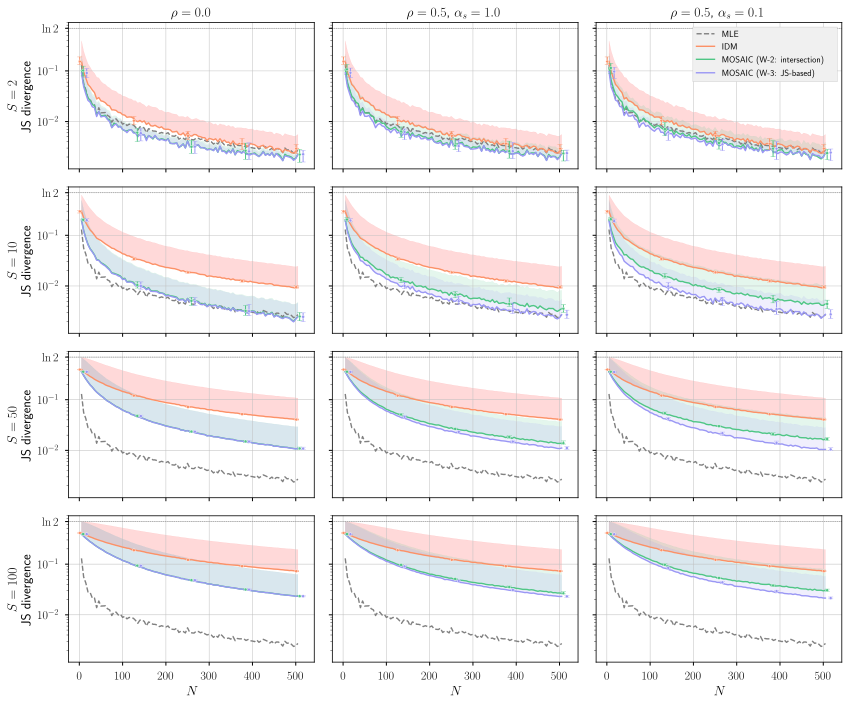

In [6]:
# Plot 1: center-to-max credal-set band per facet; the minimum is not
# shown, since a wider interval trivially lowers it without being better.
mos_colors = {2: "#4fc685", 3: "#9a97f4"}
mos_labels = {
    2: "MOSAIC (W-2: intersection)",
    3: "MOSAIC (W-3: JS-based)",
}
# Fixed dodge slot per method, also used as the draw order (which
# matplotlib uses as the legend order too).
mos_dodge = {2: 0.5, 3: 1.5}

fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(SUBPLOT_WIDTH * len(col_vals), SUBPLOT_HEIGHT * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for i, (nc, ess) in enumerate(row_vals):
    for j, (p, a) in enumerate(col_vals):
        ax = axes[i][j]
        ax.grid(
            True, which="major", linestyle="-", linewidth=0.5, color="#bfbfbf", zorder=1
        )
        sub = df_mean[
            (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
            & (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
        ].sort_values("size")

        mle_center, mle_spread = center_spread(sub, "mle")
        ax.plot(
            sub["size"],
            mle_center,
            "--",
            linewidth=CURVE_LINEWIDTH,
            color="grey",
            label="MLE",
        )
        # Uncomment to also show MLE's own repetition variability:
        # add_std_whiskers(ax, sub["size"], mle_center, mle_spread, color="grey", dodge=-1.5 * WHISKER_DODGE, clip_lower=1e-6)

        idm_center, idm_spread = center_spread(sub, "idm_mean")
        idm_max_center, _ = center_spread(sub, "idm_max")
        ax.fill_between(
            sub["size"], idm_center, idm_max_center, color="red", alpha=0.15
        )
        ax.plot(
            sub["size"],
            idm_center,
            "-",
            color="#fc9167",
            linewidth=CURVE_LINEWIDTH,
            label="IDM",
        )
        add_std_whiskers(
            ax,
            sub["size"],
            idm_center,
            idm_spread,
            color="#fc9167",
            dodge=-0.5 * WHISKER_DODGE,
            clip_lower=1e-6,
        )
        for w, color in mos_colors.items():
            mos_center, mos_spread = center_spread(sub, f"mos_w{w}_mean")
            mos_max_center, _ = center_spread(sub, f"mos_w{w}_max")
            ax.fill_between(
                sub["size"],
                mos_center,
                mos_max_center,
                color=color,
                alpha=0.15,
            )
            ax.plot(
                sub["size"],
                mos_center,
                color=color,
                linewidth=CURVE_LINEWIDTH,
                label=mos_labels[w],
            )
            add_std_whiskers(
                ax,
                sub["size"],
                mos_center,
                mos_spread,
                color=color,
                dodge=mos_dodge[w] * WHISKER_DODGE,
                clip_lower=1e-6,
            )

        ax.set_yscale("log")
        # jsd() uses natural log, so the max is ln(2) nats, not 1 (the log2
        # convention); 0 itself can't be drawn on this log-scale axis.
        ax.axhline(np.log(2), color="gray", linewidth=0.7, linestyle=":")
        if i == 0:
            ax.set_title(col_label(p, a), fontsize=COL_TITLE_FONTSIZE)
        if j == 0:
            ax.set_ylabel(
                f"{row_label(nc, ess)}\nJS divergence", fontsize=ROW_LABEL_FONTSIZE
            )
        if i == len(row_vals) - 1:
            ax.set_xlabel("$N$")

# Trim the automatic log-scale margin above ln(2); otherwise the axis
# extends to 10^1, crowding the "ln 2" tick against "10^0".
axes[0][0].set_ylim(top=0.9)

# Add ln(2) as an extra y-tick label on each row's leftmost panel
# (sharey hides tick labels on the rest).
fig.canvas.draw()
for i in range(len(row_vals)):
    ax0 = axes[i][0]
    ymin, ymax = ax0.get_ylim()
    ax0.set_yticks([1e-2, 1e-1, np.log(2)])
    ax0.set_yticklabels([r"$10^{-2}$", r"$10^{-1}$", r"$\ln 2$"])

axes[0][-1].legend(
    loc="upper right",
    frameon=True,
    fancybox=False,
    framealpha=1,
    facecolor="#f0f0f0",
    edgecolor="#a8a8a8",
)

plt.tight_layout()
plt.show()
# Save figure
fig.savefig(f"results_proximity.png", dpi=1000, bbox_inches="tight", transparent=False)

In [7]:
# # Plot: intersection ratio per grid combination. Meaningful for weighting=2
# # (hard intersection); computed for all schemas regardless.
# fig, axes = plt.subplots(
#     len(row_vals),
#     len(col_vals),
#     figsize=(SUBPLOT_WIDTH * len(col_vals), SUBPLOT_HEIGHT * len(row_vals)),
#     squeeze=False,
#     sharex=True,
#     sharey=True,
# )

# for i, (nc, ess) in enumerate(row_vals):
#     for j, (p, a) in enumerate(col_vals):
#         ax = axes[i][j]
#         sub = df_mean[
#             (df_mean["prob_shift"] == p)
#             & (df_mean["alpha"] == a)
#             & (df_mean["n_clients"] == nc)
#             & (df_mean["ess"] == ess)
#         ].sort_values("size")

#         ax.plot(
#             sub["size"], sub["intersection_frac_median"], color="green", linewidth=CURVE_LINEWIDTH, label="Median"
#         )
#         add_std_whiskers(
#             ax, sub["size"], sub["intersection_frac_median"],
#             (
#                 sub["intersection_frac_median"] - sub["intersection_frac_q1"],
#                 sub["intersection_frac_q3"] - sub["intersection_frac_median"],
#             ),
#             color="green",
#         )

#         if i == 0:
#             ax.set_title(col_label(p, a), fontsize=COL_TITLE_FONTSIZE)
#         if j == 0:
#             ax.set_ylabel(
#                 f"{row_label(nc, ess)}\nC-set intersection ratio", fontsize=ROW_LABEL_FONTSIZE
#             )
#         if i == len(row_vals) - 1:
#             ax.set_xlabel("$N$")

# axes[0][-1].legend(loc="upper right")

# plt.tight_layout()
# plt.show()

# # Save figure
# fig.savefig(
#     f"{res_path}_intersection.png", dpi=1000, bbox_inches="tight", transparent=False
# )

## Plot 1.1: relative gain of each weighting schema over IDM

$\text{gain}_w = (\text{JSD}_{\text{IDM,mean}} - \text{JSD}_{\text{MOSAIC-}w\text{,mean}}) / \text{JSD}_{\text{IDM,mean}}$, computed per repetition, then averaged. Positive = MOSAIC closer to the ground truth than plain local IDM. Shown via sparse whisker markers for the across-repetition spread (mean $\pm$ std or median $\pm$ Q1/Q3, depending on `CENTRAL_STAT`): how reproducible the gain is if the whole experiment were repeated, not a measure of how wide a single credal set is (that's Plot 1's center-to-max band).

In [8]:
# fig, axes = plt.subplots(
#     len(row_vals),
#     len(col_vals),
#     figsize=(SUBPLOT_WIDTH * len(col_vals), SUBPLOT_HEIGHT * len(row_vals)),
#     squeeze=False,
#     sharex=True,
#     sharey=True,
# )

# for i, (nc, ess) in enumerate(row_vals):
#     for j, (p, a) in enumerate(col_vals):
#         ax = axes[i][j]
#         sub = df_mean[
#             (df_mean["prob_shift"] == p)
#             & (df_mean["alpha"] == a)
#             & (df_mean["n_clients"] == nc)
#             & (df_mean["ess"] == ess)
#         ].sort_values("size")

#         ax.axhline(0.0, color="gray", linewidth=0.7, linestyle=":")
#         for w, color in mos_colors.items():
#             m, s = center_spread(sub, f"gain_w{w}")
#             ax.plot(sub["size"], m, color=color, linewidth=CURVE_LINEWIDTH, label=mos_labels[w])
#             add_std_whiskers(ax, sub["size"], m, s, color=color, dodge=mos_dodge[w] * WHISKER_DODGE)

#         if i == 0:
#             ax.set_title(col_label(p, a), fontsize=COL_TITLE_FONTSIZE)
#         if j == 0:
#             ax.set_ylabel(f"{row_label(nc, ess)}\nRelative gain vs IDM", fontsize=ROW_LABEL_FONTSIZE)
#         if i == len(row_vals) - 1:
#             ax.set_xlabel("$N$")

# axes[0][-1].legend(loc="upper right")

# plt.tight_layout()
# plt.show()

# fig.savefig(f"{res_path}_gain.png", dpi=1000, bbox_inches="tight", transparent=False)

## Plot 1.2: ground-truth containment ratio

Fraction of CPT entries across the network where the TRUE (ground-truth) parameters are actually contained in the credal set (`gt_containment_frac`, `src/utils.py`): the empirical check of "Reliability of credal sets" (`cap6_extract.tex`, Definition `as:credal`). Unlike $\widehat{\theta}^e$ (the MLE, always inside the local IDM credal set for any ess, an algebraic fact, see `exp_local.py`), containment of the true, unknown parameters is **not** guaranteed. This is expected to be MOSAIC's "negative" result: a narrower, more precise credal set can come at the cost of lower containment than IDM alone. Shown via sparse whisker markers for the across-repetition spread (mean $\pm$ std or median $\pm$ Q1/Q3, depending on `CENTRAL_STAT`).

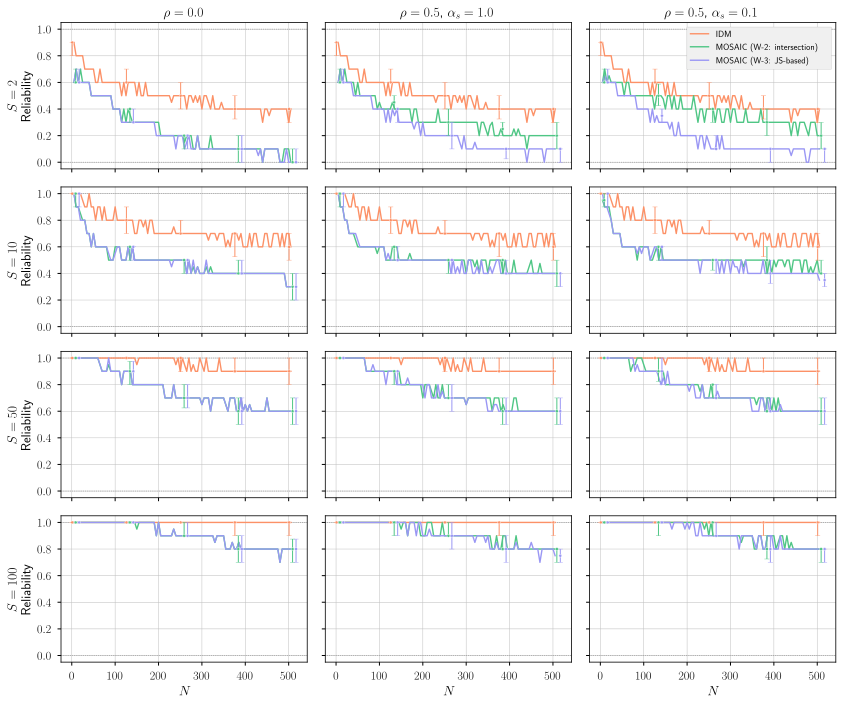

In [9]:
# IDM first, then MOSAIC W-2/W-3: same draw/legend order and dodge slots
# as every other plot (see mos_dodge in Plot 1's cell).
contain_colors = {"idm": "#fc9167", **mos_colors}
contain_labels = {"idm": "IDM", **mos_labels}
contain_dodge = {"idm": -0.5, 2: 0.5, 3: 1.5}

fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(SUBPLOT_WIDTH * len(col_vals), SUBPLOT_HEIGHT * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for i, (nc, ess) in enumerate(row_vals):
    for j, (p, a) in enumerate(col_vals):
        ax = axes[i][j]
        ax.grid(
            True, which="major", linestyle="-", linewidth=0.5, color="#bfbfbf", zorder=1
        )
        sub = df_mean[
            (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
            & (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
        ].sort_values("size")

        ax.axhline(0.0, color="gray", linewidth=0.7, linestyle=":")
        ax.axhline(1.0, color="gray", linewidth=0.7, linestyle=":")
        for kind, color in contain_colors.items():
            prefix = (
                "idm_gt_contained" if kind == "idm" else f"mos_w{kind}_gt_contained"
            )
            m, s = center_spread(sub, prefix)
            ax.plot(
                sub["size"],
                m,
                color=color,
                linewidth=CURVE_LINEWIDTH,
                label=contain_labels[kind],
            )
            add_std_whiskers(
                ax,
                sub["size"],
                m,
                s,
                color=color,
                dodge=contain_dodge[kind] * WHISKER_DODGE,
            )

        ax.set_ylim(-0.05, 1.05)
        if i == 0:
            ax.set_title(col_label(p, a), fontsize=COL_TITLE_FONTSIZE)
        if j == 0:
            ax.set_ylabel(
                f"{row_label(nc, ess)}\n Reliability",
                fontsize=ROW_LABEL_FONTSIZE,
            )
        if i == len(row_vals) - 1:
            ax.set_xlabel("$N$")

axes[0][-1].legend(
    loc="upper right",
    frameon=True,
    fancybox=False,
    framealpha=1,
    facecolor="#f0f0f0",
    edgecolor="#a8a8a8",
)

plt.tight_layout()
plt.show()

fig.savefig(
    f"results_reliability.png", dpi=1000, bbox_inches="tight", transparent=False
)

## Loading a saved model (`results/models/<task_id>.pkl`)

Reference example for reading back a model saved by `exp_local.py`. The global optimization phase (`exp_global.py`, `plot_global.ipynb`) reads its own saved models the same way, one client's worth of keys at a time. **Always go through `lookup_cpt_row`**, never `cpt.topandas()` or a hand-rolled row index (see `snapshot_cpts`/`lookup_cpt_row` in `src/utils.py` for why).

Models are archived **one file per task** (`results/models/<n_clients>_<ess>_<prob_shift>_<alpha>_<size>_<rep>.pkl`, see `exp_local.py`'s `_model_filename`) instead of a single `models.pkl` for the whole grid. Saving is off by default (`save_models: false` in `conf_local.yaml`) since it slows down a plain sweep; this demo only works when a run had `save_models: true`.

In [10]:
import pickle
from src.utils import lookup_cpt_row

models_dir = res_path / "models"
model_files = sorted(models_dir.glob("*.pkl"))
print(f"{len(model_files)} saved models found in {models_dir}")

if not model_files:
    print(
        "No saved models: set save_models: true in conf_local.yaml and rerun exp_local.py."
    )
else:
    # The filename itself is the task_id (n_clients, ess, prob_shift, alpha, size, rep).
    model_path = model_files[0]
    print(
        "Example task_id (n_clients, ess, prob_shift, alpha, size, rep):",
        model_path.stem,
    )

    with open(model_path, "rb") as f:
        model = pickle.load(f)
    print("Available model kinds:", sorted(model.keys()))

    # Read P(Cancer | Pollution, Smoker) from client 0's updated credal set.
    entry = model["mos_w3_min"]["C"]
    print("\nC's parent configurations (row order):", entry["parents"])
    print("C's own category labels (column order):", entry["labels"])

    row = lookup_cpt_row(entry, parents={"P": "low", "S": "True"})
    print(
        "\nP(C | P=low, S=True)  [MOSAIC w3, lower bound] =",
        dict(zip(entry["labels"], row)),
    )

    # A root variable (no parents) is read the same way, with parents=None.
    entry_p = model["bn_mle"]["P"]
    print(
        "P(Pollution)  [client 0's exact MLE] =",
        dict(zip(entry_p["labels"], lookup_cpt_row(entry_p))),
    )

0 saved models found in results_local/models
No saved models: set save_models: true in conf_local.yaml and rerun exp_local.py.
